# 🔬 OMR Pipeline — Step-by-Step Visual Walkthrough

This notebook runs **every stage** of the OMR pipeline on a single image and **displays the result** at each step so you can see exactly what is happening.

| Step | What happens |
|------|-------------|
| 1 | Imports & paths |
| 2 | Load images |
| 3 | SIFT feature detection & matching |
| 4 | Homography & image registration |
| 5 | Shadow removal |
| 6 | CLAHE contrast enhancement |
| 7 | Adaptive thresholding (binary mask) |
| 8 | Contour detection & section finding |
| 9 | Bubble contour filtering |
| 10 | Grid mapping (15×16) |
| 11 | Question–answer label assignment |
| 12 | Filled bubble detection (Otsu + pixel count) |
| 13 | Final annotated result |
| 14 | Dataset evaluation & accuracy report |

---
## Step 1 — Imports & Configuration

In [140]:
import os, re, json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import imutils
from imutils import contours

# ── Paths ── adjust these to your dataset ──────────────────────────────────
IMG_REF_PATH     = '../synthetic/ref.png'               # clean reference sheet
IMG_SAMPLE_PATH  = '../synth100/processed_data/synthetic_sample_95.png'  # one sample to visualise
PROCESSED_DIR    = '../synth100/processed_data'
LABELS_CSV       = '../synth100/labels.csv'
# ──────────────────────────────────────────────────────────────────────────

def show(title, img, cmap=None, figsize=(10, 6)):
    """Display an OpenCV image inline with matplotlib."""
    plt.figure(figsize=figsize)
    if cmap is None and len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap if cmap else 'gray')
    plt.title(title, fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def show_side(titles, images, cmaps=None, figsize=(16, 5)):
    """Display multiple images side by side."""
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1: axes = [axes]
    for ax, title, img, cmap in zip(axes, titles, images, (cmaps or [None]*n)):
        if cmap is None and len(img.shape) == 3:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(img, cmap=cmap if cmap else 'gray')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print('✅ Libraries loaded. Paths configured.')

✅ Libraries loaded. Paths configured.


---
## Step 2 — Load Reference & Sample Images

Reference shape : (1169, 827, 3)
Sample shape    : (1705, 1087, 3)


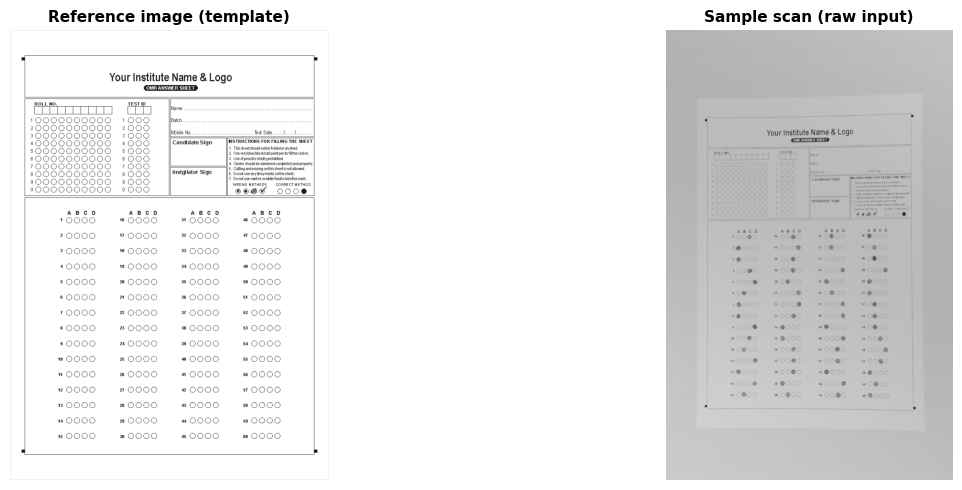

In [141]:
img_ref    = cv2.imread(IMG_REF_PATH)
img_sample = cv2.imread(IMG_SAMPLE_PATH)

assert img_ref    is not None, f'Reference image not found: {IMG_REF_PATH}'
assert img_sample is not None, f'Sample image not found: {IMG_SAMPLE_PATH}'

print(f'Reference shape : {img_ref.shape}')
print(f'Sample shape    : {img_sample.shape}')

show_side(
    ['Reference image (template)', 'Sample scan (raw input)'],
    [img_ref, img_sample]
)

---
## Step 3 — SIFT Feature Detection & Matching

SIFT finds **keypoints** in both images and describes them with 128-dim vectors.  
**Lowe's ratio test** (threshold = 0.75) keeps only reliable matches.

Keypoints in reference : 2411
Keypoints in sample    : 1575
Good matches after ratio test: 288


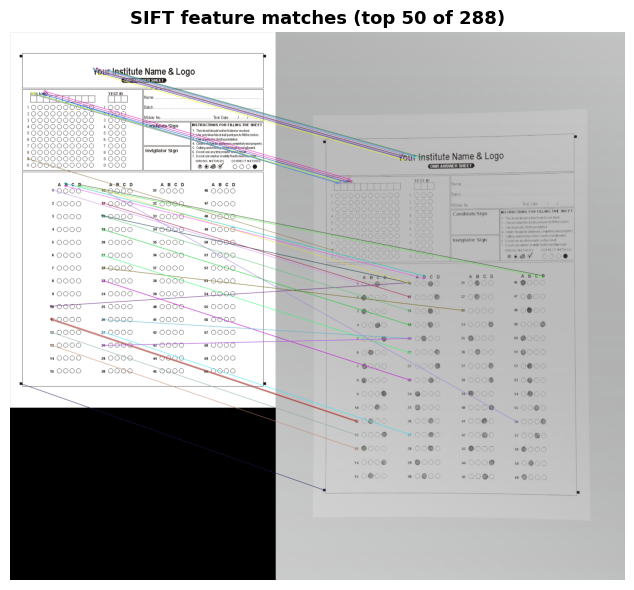

In [142]:
gray_ref    = cv2.cvtColor(img_ref,    cv2.COLOR_BGR2GRAY)
gray_sample = cv2.cvtColor(img_sample, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(gray_ref,    None)
kp2, des2 = sift.detectAndCompute(gray_sample, None)

print(f'Keypoints in reference : {len(kp1)}')
print(f'Keypoints in sample    : {len(kp2)}')

# Lowe's ratio test
good_matches = []
for i, d1 in enumerate(des1):
    distances   = np.linalg.norm(des2 - d1, axis=1)
    idx_sorted  = np.argsort(distances)
    dist_m = distances[idx_sorted[0]]
    dist_n = distances[idx_sorted[1]]
    if dist_m < 0.75 * dist_n:
        good_matches.append(cv2.DMatch(_queryIdx=i, _trainIdx=int(idx_sorted[0]), _distance=dist_m))

print(f'Good matches after ratio test: {len(good_matches)}')

# Draw top 50 matches
match_img = cv2.drawMatches(
    img_ref, kp1, img_sample, kp2,
    good_matches[:50], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)
show(f'SIFT feature matches (top 50 of {len(good_matches)})', match_img, figsize=(16, 6))

---
## Step 4 — Homography Estimation & Image Registration

RANSAC fits a homography matrix from the good matches.  
The sample is then **warped** so its layout exactly overlaps the reference.

RANSAC inliers : 231 / 288
Homography matrix:
[[ 9.637000e-01 -1.500000e-03 -1.106622e+02]
 [ 1.450000e-02  9.369000e-01 -2.484865e+02]
 [-0.000000e+00 -0.000000e+00  1.000000e+00]]


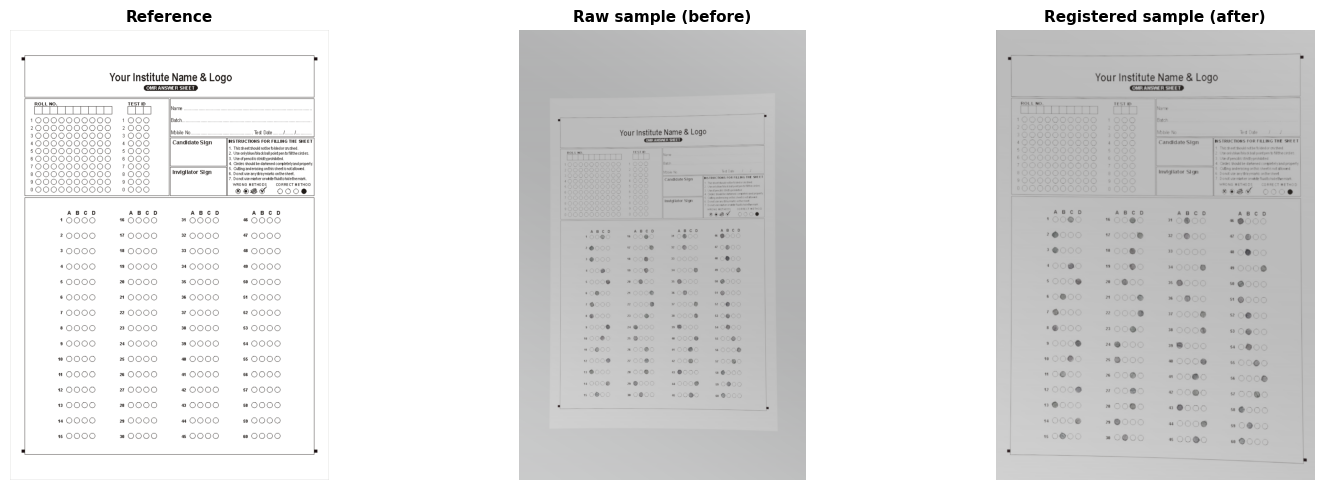

In [143]:
points1 = np.array([kp1[m.queryIdx].pt for m in good_matches], dtype=np.float32)
points2 = np.array([kp2[m.trainIdx].pt for m in good_matches], dtype=np.float32)

h_matrix, ransac_mask = cv2.findHomography(points2, points1, cv2.RANSAC, 5.0)
inliers = int(ransac_mask.sum())
print(f'RANSAC inliers : {inliers} / {len(good_matches)}')
print(f'Homography matrix:\n{np.round(h_matrix, 4)}')

height, width = img_ref.shape[:2]
registered = cv2.warpPerspective(img_sample, h_matrix, (width, height))
cv2.imwrite('warp.png', registered)

show_side(
    ['Reference', 'Raw sample (before)', 'Registered sample (after)'],
    [img_ref, img_sample, registered]
)

---
## Step 5 — Shadow Removal

Morphological **dilation** expands bright areas to estimate the lighting background.  
Subtracting it from the original removes shadows and uneven illumination.

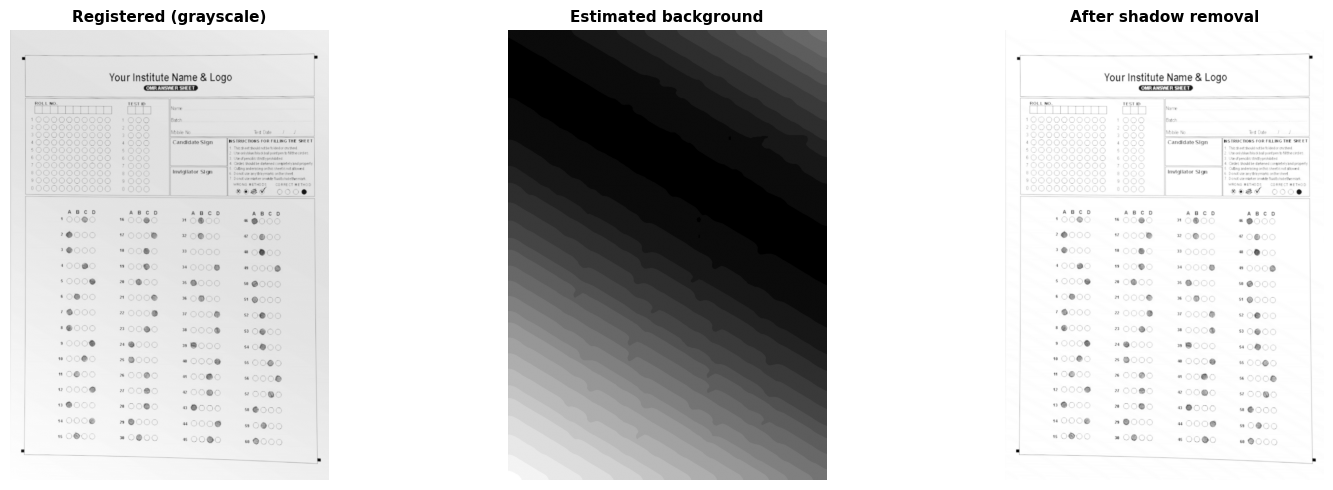

In [144]:
img_gray = cv2.imread('warp.png', cv2.IMREAD_GRAYSCALE)

se      = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
bg_img  = cv2.dilate(img_gray, se)
bg_img  = cv2.medianBlur(bg_img, 21)
diff    = 255 - cv2.absdiff(img_gray, bg_img)
norm    = cv2.normalize(diff, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8UC1)

show_side(
    ['Registered (grayscale)', 'Estimated background', 'After shadow removal'],
    [img_gray, bg_img, norm],
    cmaps=['gray', 'gray', 'gray']
)

---
## Step 6 — CLAHE Contrast Enhancement

**CLAHE** (Contrast Limited Adaptive Histogram Equalization) boosts local contrast tile-by-tile,  
making lightly-pencilled bubbles much more visible without amplifying noise.

/var/folders/xc/q7hkt_497c19ctl27w5zqjzc0000gn/T/ipykernel_85396/791122223.py:9: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1, 0].hist(norm.ravel(),     256, [0, 256], color='steelblue',  alpha=0.8); axes[1, 0].set_title('Histogram — before'); axes[1, 0].set_xlim([0,255])
/var/folders/xc/q7hkt_497c19ctl27w5zqjzc0000gn/T/ipykernel_85396/791122223.py:10: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1, 1].hist(enhanced.ravel(), 256, [0, 256], color='darkorange', alpha=0.8); axes[1, 1].set_title('Histogram — after');  axes[1, 1].set_xlim([0,255])


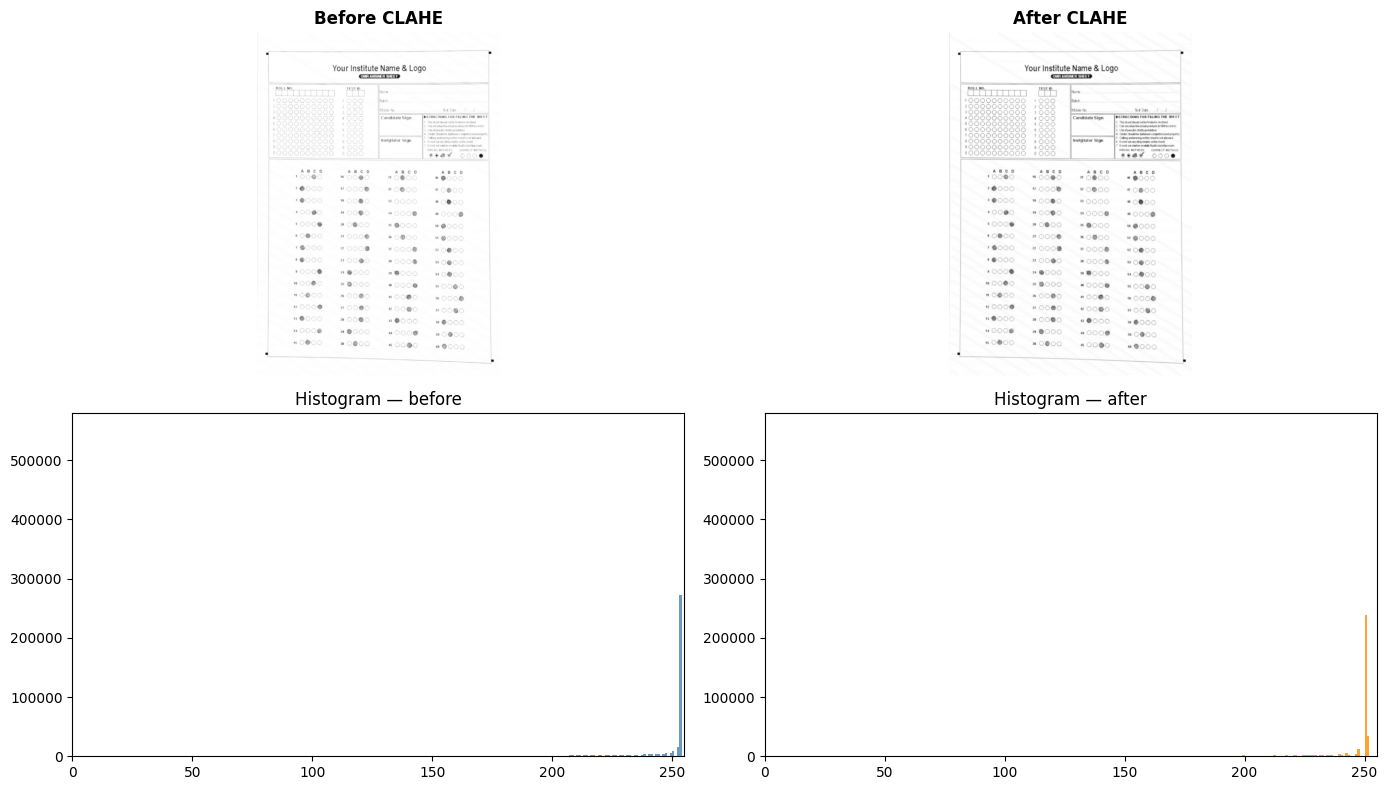

CLAHE applied. Saved → clean_background.png


In [145]:
clahe    = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
enhanced = clahe.apply(norm)
cv2.imwrite('clean_background.png', enhanced)

# Histogram comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].imshow(norm,     cmap='gray'); axes[0, 0].set_title('Before CLAHE', fontweight='bold'); axes[0, 0].axis('off')
axes[0, 1].imshow(enhanced, cmap='gray'); axes[0, 1].set_title('After CLAHE',  fontweight='bold'); axes[0, 1].axis('off')
axes[1, 0].hist(norm.ravel(),     256, [0, 256], color='steelblue',  alpha=0.8); axes[1, 0].set_title('Histogram — before'); axes[1, 0].set_xlim([0,255])
axes[1, 1].hist(enhanced.ravel(), 256, [0, 256], color='darkorange', alpha=0.8); axes[1, 1].set_title('Histogram — after');  axes[1, 1].set_xlim([0,255])
plt.tight_layout()
plt.show()
print('CLAHE applied. Saved → clean_background.png')

---
## Step 7 — Adaptive Thresholding (Binary Mask)

**Adaptive Gaussian thresholding** converts the enhanced image to a binary mask.  
Each pixel is compared to the local weighted mean of its neighbourhood (block=31, C=7).

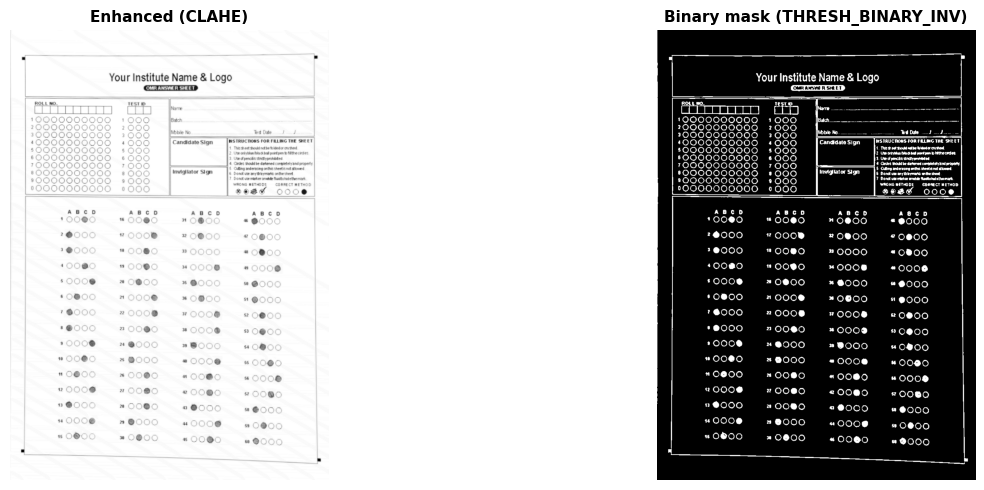

White (foreground) pixels : 93,096  (9.6%)
Black (background) pixels : 873,667


In [146]:
thresh_mask = cv2.adaptiveThreshold(
    enhanced, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    31, 7
)

show_side(
    ['Enhanced (CLAHE)', 'Binary mask (THRESH_BINARY_INV)'],
    [enhanced, thresh_mask],
    cmaps=['gray', 'gray']
)

white_px = cv2.countNonZero(thresh_mask)
total_px = thresh_mask.size
print(f'White (foreground) pixels : {white_px:,}  ({100*white_px/total_px:.1f}%)')
print(f'Black (background) pixels : {total_px - white_px:,}')

---
## Step 8 — Contour Detection & Answer Section Finding

Contours are extracted from the binary mask. Each candidate region is scored by counting  
how many valid OMR circles it contains. The first region with **≥ 236 circles** is selected.

Total contours found: 338
✅ Target section found at (29,431) size 777×697  — 240 circles


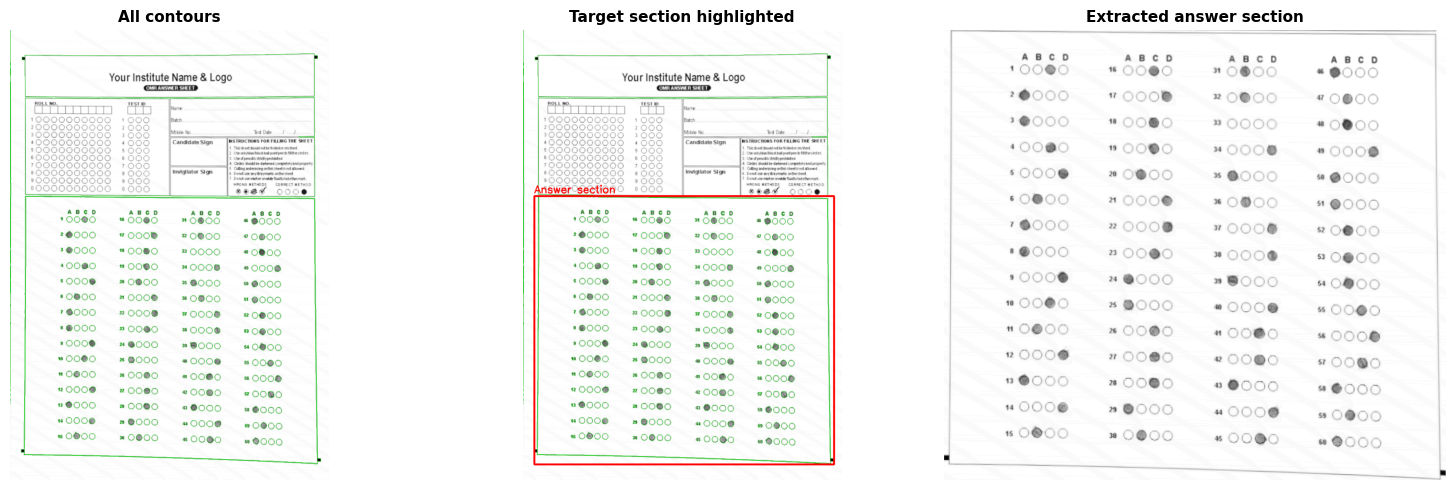

In [147]:
img_clean = cv2.imread('clean_background.png')
# Need colour version for drawing
img_clean_bgr = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)

cnts, _ = cv2.findContours(thresh_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f'Total contours found: {len(cnts)}')

# Draw ALL contours
all_cnts_img = img_clean_bgr.copy()
cv2.drawContours(all_cnts_img, cnts, -1, (0, 200, 0), 1)

def count_omr_circles(roi_img):
    gray = cv2.cvtColor(roi_img, cv2.COLOR_BGR2GRAY) if len(roi_img.shape)==3 else roi_img.copy()
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    closed = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel)
    t = cv2.adaptiveThreshold(closed, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 5)
    cs = imutils.grab_contours(cv2.findContours(t.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE))
    return sum(1 for c in cs if 100 <= cv2.contourArea(c) <= 300
               and 0.5 <= cv2.boundingRect(c)[2]/float(cv2.boundingRect(c)[3]) <= 1.5)

# Score each candidate
found_target = False
roi = None
scores = []
for cnt in cnts:
    peri  = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.02*peri, True)
    x, y, w, h = cv2.boundingRect(approx)
    if w > 100 and h > 50:
        roi_temp     = img_clean_bgr[y:y+h, x:x+w]
        circle_count = count_omr_circles(roi_temp)
        scores.append((circle_count, x, y, w, h))
        if circle_count >= 236 and not found_target:
            roi = roi_temp.copy()
            found_target = True
            target_box   = (x, y, w, h)
            print(f'✅ Target section found at ({x},{y}) size {w}×{h}  — {circle_count} circles')
            cv2.imwrite('target_section.png', roi)

# Annotate the winning box
annotated = all_cnts_img.copy()
if found_target:
    x, y, w, h = target_box
    cv2.rectangle(annotated, (x,y), (x+w, y+h), (0, 0, 255), 3)
    cv2.putText(annotated, 'Answer section', (x, y-8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,0,255), 2)

show_side(
    ['All contours', 'Target section highlighted', 'Extracted answer section'],
    [all_cnts_img, annotated, roi]
)

---
## Step 9 — Bubble Contour Filtering

Inside the extracted section, contours are filtered by **area** (100–300 px²) and  
**aspect ratio** (0.5–1.5) to isolate genuine OMR bubbles.

Total contours    : 430
Valid bubbles     : 240
Rejected (noise)  : 190


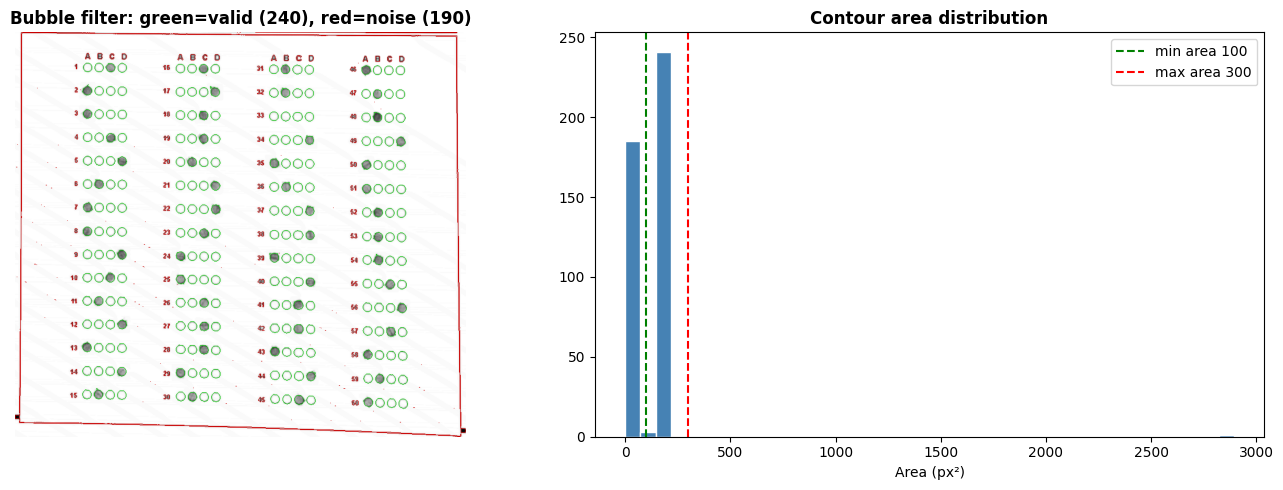

In [148]:
roi_gray = cv2.imread('target_section.png', cv2.IMREAD_GRAYSCALE)
kernel   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
closed   = cv2.morphologyEx(roi_gray, cv2.MORPH_OPEN, kernel)
thresh_roi = cv2.adaptiveThreshold(closed, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 11, 5)

all_bubble_cnts = imutils.grab_contours(
    cv2.findContours(thresh_roi.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
)

areas = [cv2.contourArea(c) for c in all_bubble_cnts]
filtered_cnts = []
rejected_cnts = []
for c in all_bubble_cnts:
    area = cv2.contourArea(c)
    x, y, w, h = cv2.boundingRect(c)
    ar = w / float(h)
    if 100 <= area <= 300 and 0.5 <= ar <= 1.5:
        filtered_cnts.append(c)
    else:
        rejected_cnts.append(c)

print(f'Total contours    : {len(all_bubble_cnts)}')
print(f'Valid bubbles     : {len(filtered_cnts)}')
print(f'Rejected (noise)  : {len(rejected_cnts)}')

# Visualise
vis = cv2.cvtColor(roi_gray, cv2.COLOR_GRAY2BGR)
cv2.drawContours(vis, rejected_cnts, -1, (0, 0, 200),  1)   # red  = rejected
cv2.drawContours(vis, filtered_cnts, -1, (0, 200, 0),  1)   # green = accepted

# Area histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Bubble filter: green=valid ({len(filtered_cnts)}), red=noise ({len(rejected_cnts)})', fontweight='bold')
axes[0].axis('off')
axes[1].hist(areas, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(100, color='green',  linestyle='--', label='min area 100')
axes[1].axvline(300, color='red',    linestyle='--', label='max area 300')
axes[1].set_title('Contour area distribution', fontweight='bold')
axes[1].set_xlabel('Area (px²)')
axes[1].legend()
plt.tight_layout()
plt.show()

---
## Step 10 — Grid Mapping (15 rows × 16 columns)

Bubble centres are split into sorted equal groups and the median taken for each row/column.  
Every contour is then snapped to its nearest grid cell, producing exactly 240 boxes.

Grid boxes built: 240 (expected 240)


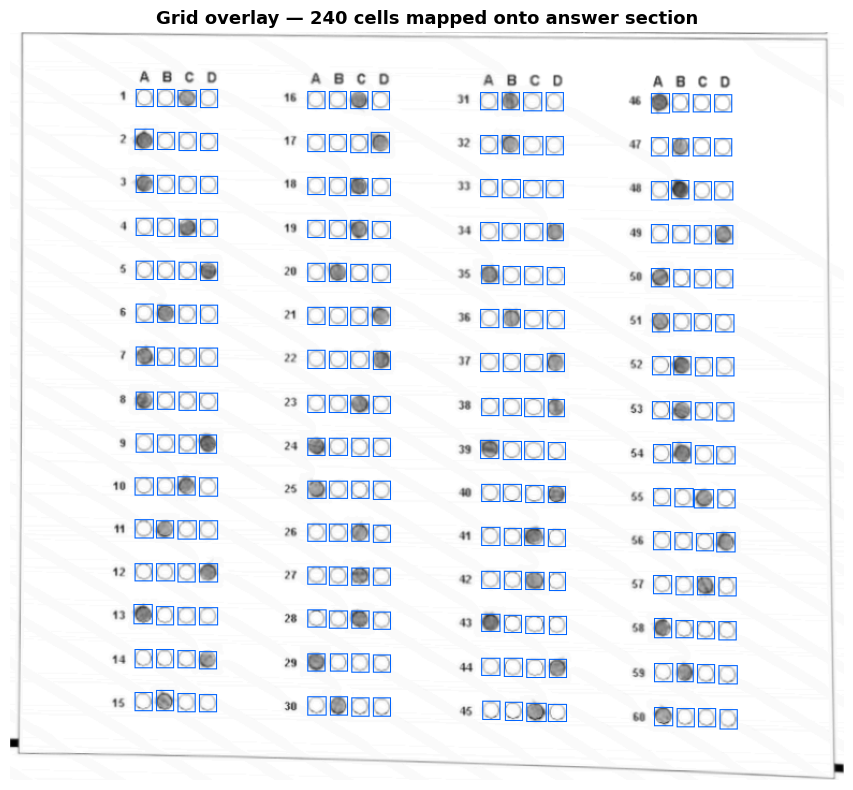

In [149]:
def _group_medians(values, groups):
    if len(values) == 0: return []
    if len(values) < groups:
        return list(np.linspace(float(np.min(values)), float(np.max(values)), groups))
    splits = np.array_split(np.sort(values), groups)
    return [float(np.median(s)) for s in splits]

def build_grid_from_contours(cnts, rows=15, cols=16):
    if not cnts: return []
    centers, widths, heights = [], [], []
    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        centers.append((x+w/2.0, y+h/2.0, x, y, w, h))
        widths.append(w); heights.append(h)
    col_centers = _group_medians([c[0] for c in centers], cols)
    row_centers = _group_medians([c[1] for c in centers], rows)
    median_w = int(np.median(widths))
    median_h = int(np.median(heights))
    grid = {}
    for cx, cy, x, y, w, h in centers:
        ri = int(np.argmin([abs(cy-r) for r in row_centers]))
        ci = int(np.argmin([abs(cx-c) for c in col_centers]))
        dist = abs(cy-row_centers[ri]) + abs(cx-col_centers[ci])
        key = (ri, ci)
        if key not in grid or dist < grid[key]['dist']:
            grid[key] = {'x':x,'y':y,'w':w,'h':h,'dist':dist}
    boxes = []
    for r in range(rows):
        for c in range(cols):
            key = (r, c)
            if key in grid:
                b = grid[key]
                boxes.append({'x':int(b['x']),'y':int(b['y']),'w':int(b['w']),'h':int(b['h'])})
            else:
                boxes.append({'x':int(col_centers[c]-median_w/2),
                              'y':int(row_centers[r]-median_h/2),
                              'w':median_w,'h':median_h})
    return boxes

grid_boxes = build_grid_from_contours(filtered_cnts, rows=15, cols=16)
print(f'Grid boxes built: {len(grid_boxes)} (expected 240)')

# Visualise the grid overlay
roi_bgr = cv2.imread('target_section.png')
grid_vis = roi_bgr.copy()
for i, box in enumerate(grid_boxes):
    x, y, w, h = box['x'], box['y'], box['w'], box['h']
    cv2.rectangle(grid_vis, (x, y), (x+w, y+h), (255, 100, 0), 1)

show(f'Grid overlay — {len(grid_boxes)} cells mapped onto answer section', grid_vis, figsize=(12,8))

---
## Step 11 — Question–Answer Label Assignment

The 240 cells are arranged as **4 blocks × 15 rows**, each block holding 4 options (A–D).  
Each cell gets a label like `'1A'`, `'15D'`, `'60C'` and coordinates are saved to JSON.

omr_map built: 240 entries (60 questions × 4 options)
Saved → omr_template_map.json
Sample entries: {'1A': {'x': 117, 'y': 53, 'w': 16, 'h': 16}, '1B': {'x': 137, 'y': 53, 'w': 16, 'h': 16}, '1C': {'x': 156, 'y': 54, 'w': 17, 'h': 15}, '1D': {'x': 177, 'y': 53, 'w': 16, 'h': 17}}
Saved → omr_bubbles_only.png


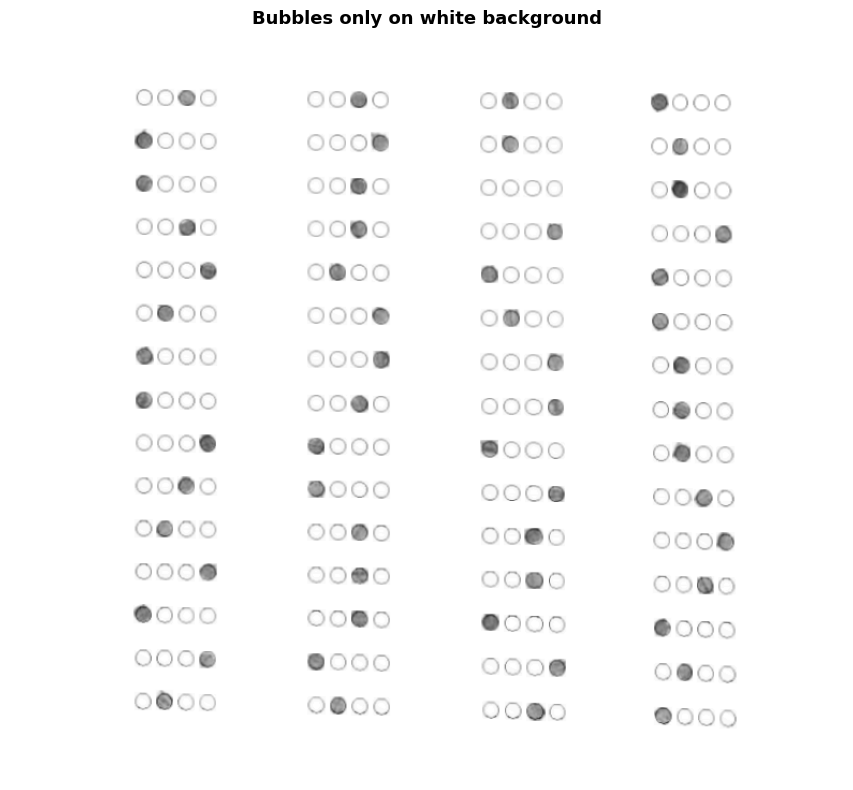

In [150]:
omr_map = {}
option_letters = ['A', 'B', 'C', 'D']

if len(grid_boxes) == 240:
    for row_idx in range(15):
        row_bubbles = grid_boxes[row_idx * 16:(row_idx + 1) * 16]
        for block_idx in range(4):
            q_num = block_idx * 15 + row_idx + 1
            options = row_bubbles[block_idx * 4:block_idx * 4 + 4]
            for opt_idx, bubble in enumerate(options):
                label = f"{q_num}{option_letters[opt_idx]}"
                omr_map[label] = {k: bubble[k] for k in ['x', 'y', 'w', 'h']}

    with open('omr_template_map.json', 'w') as f:
        json.dump(omr_map, f, indent=2)

    print(f'omr_map built: {len(omr_map)} entries (60 questions × 4 options)')
    print('Saved → omr_template_map.json')
    print(f'Sample entries: {dict(list(omr_map.items())[:4])}')
else:
    print(f'❌ Expected 240 grid boxes, got {len(grid_boxes)}')

# Save for later reuse
# Save mapping only once
with open('omr_template_map.json', 'w') as f:
    json.dump(omr_map, f, indent=2)

# White canvas
bubble_only_vis = np.ones_like(roi_bgr, dtype=roi_bgr.dtype) * 255

# Copy only bubble regions onto white background
for box in omr_map.values():
    x, y, w, h = box['x'], box['y'], box['w'], box['h']
    x1, y1 = max(0, x), max(0, y)
    x2, y2 = min(bubble_only_vis.shape[1], x + w), min(bubble_only_vis.shape[0], y + h)

    if x1 < x2 and y1 < y2:
        bubble_only_vis[y1:y2, x1:x2] = roi_bgr[y1:y2, x1:x2].copy()

# Whiten intersections between overlapping boxes
boxes = list(omr_map.values())
for i in range(len(boxes)):
    x1, y1, w1, h1 = boxes[i]['x'], boxes[i]['y'], boxes[i]['w'], boxes[i]['h']
    xa1, ya1 = max(0, x1), max(0, y1)
    xa2, ya2 = min(bubble_only_vis.shape[1], x1 + w1), min(bubble_only_vis.shape[0], y1 + h1)

    for j in range(i + 1, len(boxes)):
        x2, y2, w2, h2 = boxes[j]['x'], boxes[j]['y'], boxes[j]['w'], boxes[j]['h']
        xb1, yb1 = max(0, x2), max(0, y2)
        xb2, yb2 = min(bubble_only_vis.shape[1], x2 + w2), min(bubble_only_vis.shape[0], y2 + h2)

        ix1, iy1 = max(xa1, xb1), max(ya1, yb1)
        ix2, iy2 = min(xa2, xb2), min(ya2, yb2)

        if ix1 < ix2 and iy1 < iy2:
            bubble_only_vis[iy1:iy2, ix1:ix2] = 255

cv2.imwrite('omr_bubbles_only.png', bubble_only_vis)
print('Saved → omr_bubbles_only.png')

show('Bubbles only on white background', bubble_only_vis, figsize=(12, 8))

---
## Step 12 — Filled Bubble Detection (Otsu + Pixel Count)

**Otsu thresholding** re-binarises the section. Each candidate contour is masked and  
the white pixel count measured. Bubbles with **≥ 150 white pixels** are considered filled.

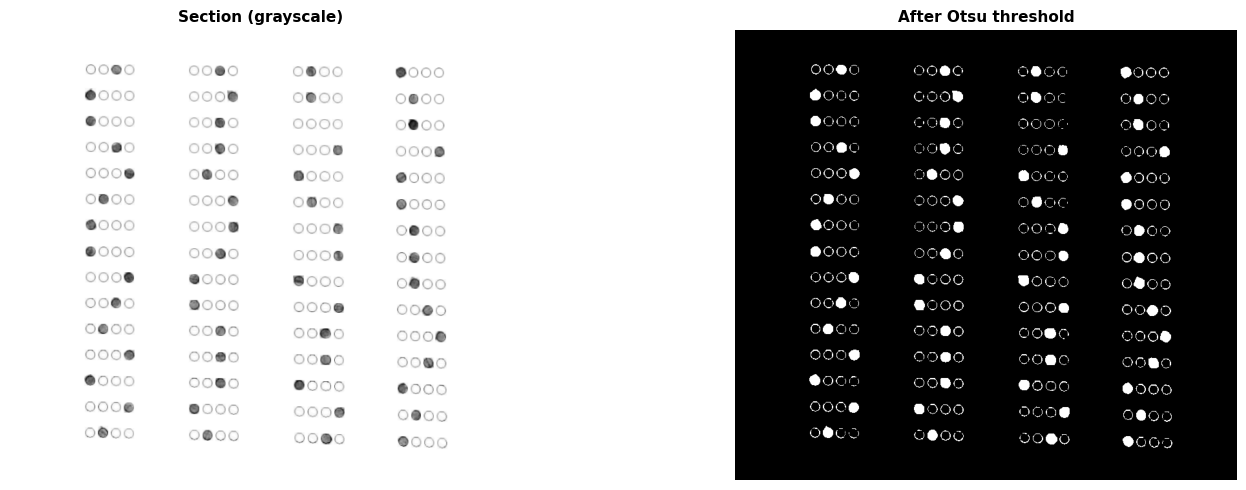

Candidate bubble contours: 210
Filled bubbles detected: 59


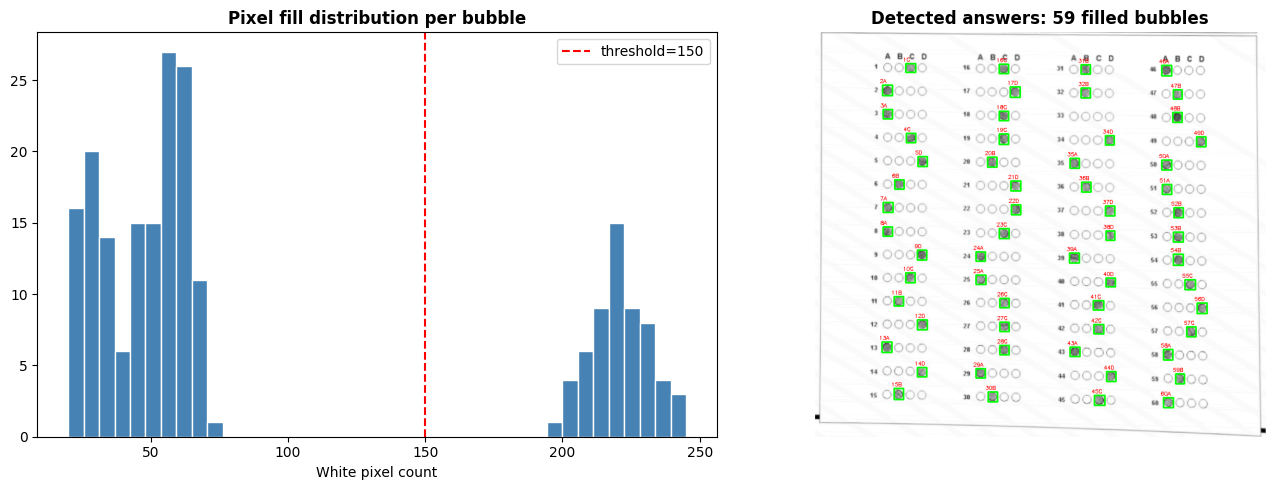

In [151]:
img_section  = cv2.imread('target_section.png')
# gray_section = cv2.cvtColor(img_section, cv2.COLOR_BGR2GRAY)

gray_section = cv2.cvtColor(bubble_only_vis, cv2.COLOR_BGR2GRAY)
_, thresh_otsu = cv2.threshold(gray_section, 0, 255,
                               cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)

show_side(
    ['Section (grayscale)', 'After Otsu threshold'],
    [gray_section, thresh_otsu],
    cmaps=['gray', 'gray']
)

final_cnts = imutils.grab_contours(
    cv2.findContours(thresh_otsu.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
)
candidate_bubbles = [c for c in final_cnts
                     if cv2.boundingRect(c)[2] >= 12
                     and cv2.boundingRect(c)[3] >= 12
                     and 0.5 <= cv2.boundingRect(c)[2]/float(cv2.boundingRect(c)[3]) <= 1.5]

print(f'Candidate bubble contours: {len(candidate_bubbles)}')

# Measure pixel fill for each candidate
def sort_key(s):
    p = re.match(r'(\d+)([A-Z])', s)
    return int(p.group(1)), p.group(2)

PIXEL_THRESHOLD = 150
filled_labels   = []
pixel_counts    = []
annotated_sec   = img_section.copy()

for c in candidate_bubbles:
    x, y, w, h = cv2.boundingRect(c)
    cx, cy = x + w//2, y + h//2
    mask_c = np.zeros(thresh_otsu.shape, dtype='uint8')
    cv2.drawContours(mask_c, [c], -1, 255, -1)
    masked     = cv2.bitwise_and(thresh_otsu, thresh_otsu, mask=mask_c)
    total_px   = cv2.countNonZero(masked)
    pixel_counts.append(total_px)

    if total_px >= PIXEL_THRESHOLD:
        matched = None
        for label, box in omr_map.items():
            buf = 5
            if (box['x']-buf <= cx <= box['x']+box['w']+buf and
                box['y']-buf <= cy <= box['y']+box['h']+buf):
                matched = label
                break
        if matched:
            filled_labels.append(matched)
            cv2.rectangle(annotated_sec, (x,y), (x+w,y+h), (0,255,0), 2)
            cv2.putText(annotated_sec, matched, (x-5, y-4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0,0,255), 1)

filled_labels.sort(key=sort_key)
print(f'Filled bubbles detected: {len(filled_labels)}')

# Pixel count distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(pixel_counts, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(PIXEL_THRESHOLD, color='red', linestyle='--', label=f'threshold={PIXEL_THRESHOLD}')
axes[0].set_title('Pixel fill distribution per bubble', fontweight='bold')
axes[0].set_xlabel('White pixel count')
axes[0].legend()
axes[1].imshow(cv2.cvtColor(annotated_sec, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Detected answers: {len(filled_labels)} filled bubbles', fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.show()

---
## Step 13 — Final Annotated Result

Full annotated output showing every detected answer on the section image,  
plus the sorted list of predicted answers.

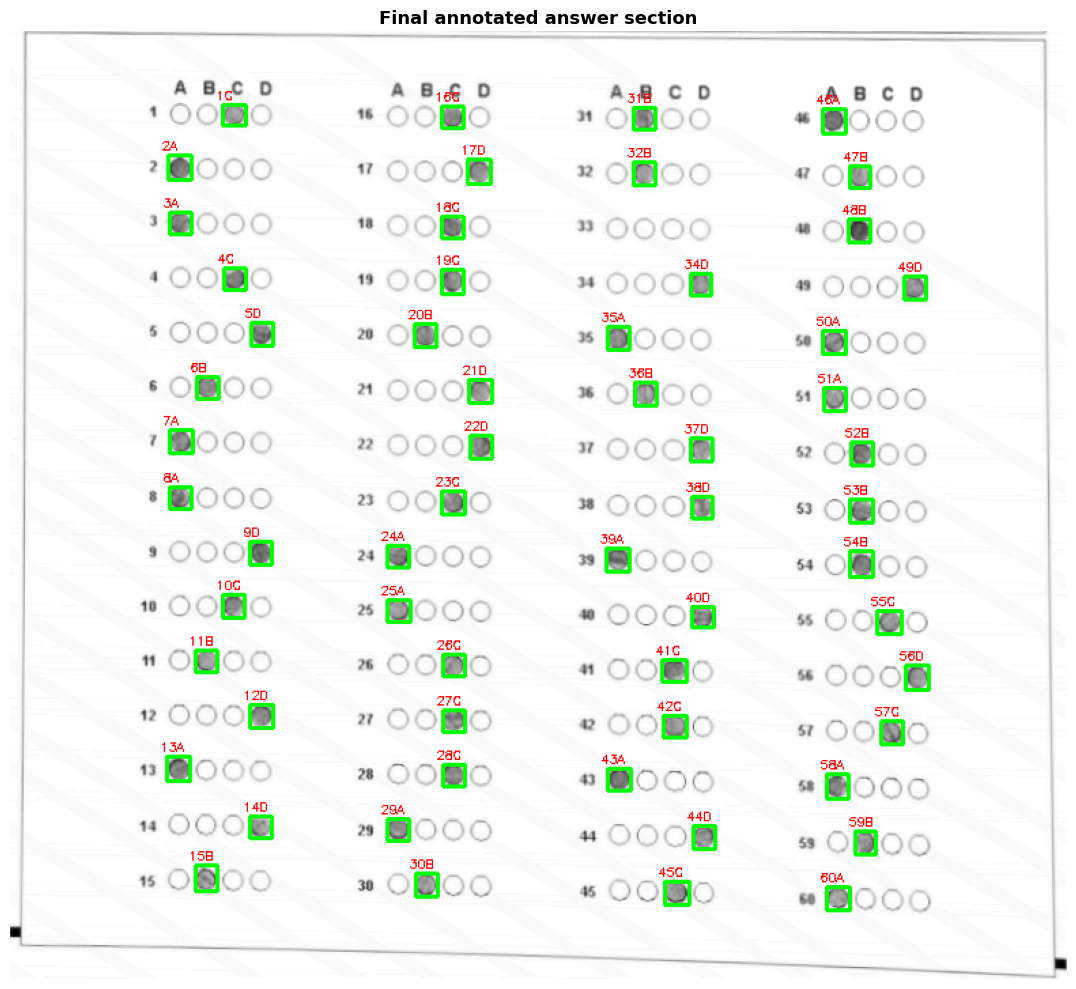

──────────────────────────────────────────────────
Predicted answers (59 total):
──────────────────────────────────────────────────
         Q1–Q15 Q16–Q30 Q31–Q45 Q46–Q60
Question                               
1             C     NaN     NaN     NaN
2             A     NaN     NaN     NaN
3             A     NaN     NaN     NaN
4             C     NaN     NaN     NaN
5             D     NaN     NaN     NaN
6             B     NaN     NaN     NaN
7             A     NaN     NaN     NaN
8             A     NaN     NaN     NaN
9             D     NaN     NaN     NaN
10            C     NaN     NaN     NaN
11            B     NaN     NaN     NaN
12            D     NaN     NaN     NaN
13            A     NaN     NaN     NaN
14            D     NaN     NaN     NaN
15            B     NaN     NaN     NaN
16          NaN       C     NaN     NaN
17          NaN       D     NaN     NaN
18          NaN       C     NaN     NaN
19          NaN       C     NaN     NaN
20          NaN       B     

In [152]:
show('Final annotated answer section', annotated_sec, figsize=(14, 10))

print('─' * 50)
print(f'Predicted answers ({len(filled_labels)} total):')
print('─' * 50)

# Group by question number for neat display
answers_dict = {int(lbl[:-1]): lbl[-1] for lbl in filled_labels}
rows = []
for q in range(1, 61):
    rows.append({'Question': q, 'Predicted': answers_dict.get(q, '—')})
df_pred = pd.DataFrame(rows).set_index('Question')

# Display in 4 columns
chunk = 15
cols_dfs = [df_pred.iloc[i:i+chunk] for i in range(0, 60, chunk)]
combined = pd.concat(cols_dfs, axis=1)
combined.columns = [f'Q{i+1}–Q{i+chunk}' for i in range(0, 60, chunk)]
print(combined.to_string())

---
## Step 14 — Full Dataset Evaluation & Accuracy Report

Run the complete pipeline over **all images** in the dataset, compare against `labels.csv`,  
and report per-image accuracy and the overall mean.

In [ ]:
# ── Helper functions (consolidated for standalone use) ────────────────────

def auto_register2(img_ref_path, img_warped_path):
    img1 = cv2.imread(img_ref_path)
    img2 = cv2.imread(img_warped_path)
    if img1 is None or img2 is None:
        raise ValueError('Could not read one of the images.')
    g1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    g2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(g1, None)
    kp2, des2 = sift.detectAndCompute(g2, None)
    good = []
    for i, d1 in enumerate(des1):
        dists = np.linalg.norm(des2 - d1, axis=1)
        idx = np.argsort(dists)
        if dists[idx[0]] < 0.75 * dists[idx[1]]:
            good.append(cv2.DMatch(_queryIdx=i, _trainIdx=int(idx[0]), _distance=dists[idx[0]]))
    if len(good) < 10: return img2
    p1 = np.array([kp1[m.queryIdx].pt for m in good], dtype=np.float32)
    p2 = np.array([kp2[m.trainIdx].pt for m in good], dtype=np.float32)
    H, _ = cv2.findHomography(p2, p1, cv2.RANSAC, 5.0)
    h, w = img1.shape[:2]
    return cv2.warpPerspective(img2, H, (w, h))

def preprocess_omr_gentle(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    se  = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    bg  = cv2.medianBlur(cv2.dilate(img, se), 21)
    norm = cv2.normalize(255 - cv2.absdiff(img, bg), None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8UC1)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    enhanced = clahe.apply(norm)
    thresh = cv2.adaptiveThreshold(enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 31, 7)
    return enhanced, thresh

def omr_pipeline(img_ref_path, img_warped_path, debug=False):
    registered = auto_register2(img_ref_path, img_warped_path)
    cv2.imwrite('warp.png', registered)
    flat_img, mask = preprocess_omr_gentle('warp.png')
    cv2.imwrite('clean_background.png', flat_img)
    img = cv2.imread('clean_background.png')
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    found_target = False; roi = None
    for cnt in cnts:
        peri  = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02*peri, True)
        x, y, w, h = cv2.boundingRect(approx)
        if w > 100 and h > 50:
            roi_temp = img[y:y+h, x:x+w]
            if count_omr_circles(roi_temp) >= 236:
                cv2.imwrite('target_section.png', roi_temp)
                roi = roi_temp; found_target = True; break
    if not found_target: return []
    roi_gray = cv2.imread('target_section.png', cv2.IMREAD_GRAYSCALE)
    kernel   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    closed   = cv2.morphologyEx(roi_gray, cv2.MORPH_OPEN, kernel)
    t_roi    = cv2.adaptiveThreshold(closed, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY_INV, 11, 5)
    bubble_cnts = imutils.grab_contours(
        cv2.findContours(t_roi.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE))
    filtered = [c for c in bubble_cnts
                if 100 <= cv2.contourArea(c) <= 300
                and 0.5 <= cv2.boundingRect(c)[2]/float(cv2.boundingRect(c)[3]) <= 1.5]
    if len(filtered) < 236: return []
    grid_boxes = build_grid_from_contours(filtered, 15, 16)
    if len(grid_boxes) != 240: return []
    omr_map = {}
    for ri in range(15):
        row_b = grid_boxes[ri*16:(ri+1)*16]
        for bi in range(4):
            q = bi*15+ri+1
            for oi, bub in enumerate(row_b[bi*4:bi*4+4]):
                omr_map[f"{q}{option_letters[oi]}"] = {k:bub[k] for k in ['x','y','w','h']}
    img_sec   = cv2.imread('target_section.png')
    gray_sec  = cv2.cvtColor(img_sec, cv2.COLOR_BGR2GRAY)
    _, t_otsu = cv2.threshold(gray_sec, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)
    final_cs  = imutils.grab_contours(
        cv2.findContours(t_otsu.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE))
    candidates = [c for c in final_cs
                  if cv2.boundingRect(c)[2]>=12 and cv2.boundingRect(c)[3]>=12
                  and 0.5 <= cv2.boundingRect(c)[2]/float(cv2.boundingRect(c)[3]) <= 1.5]
    filled = []
    for c in candidates:
        x, y, w, h = cv2.boundingRect(c)
        cx, cy = x+w//2, y+h//2
        mk = np.zeros(t_otsu.shape, dtype='uint8')
        cv2.drawContours(mk, [c], -1, 255, -1)
        if cv2.countNonZero(cv2.bitwise_and(t_otsu, t_otsu, mask=mk)) >= 150:
            for lbl, box in omr_map.items():
                if (box['x']-5 <= cx <= box['x']+box['w']+5 and
                    box['y']-5 <= cy <= box['y']+box['h']+5):
                    filled.append(lbl); break
    filled.sort(key=sort_key)
    return filled

# ── Run evaluation ────────────────────────────────────────────────────────
if os.path.exists(LABELS_CSV) and os.path.exists(PROCESSED_DIR):
    df_gt     = pd.read_csv(LABELS_CSV)
    filenames = sorted(os.listdir(PROCESSED_DIR),
                       key=lambda x: int(re.match(r'synthetic_sample_(\d+)\.png', x).group(1)))

    results = []
    for pic in filenames:
        path       = os.path.join(PROCESSED_DIR, pic)
        predicted  = omr_pipeline(IMG_REF_PATH, path, debug=False)
        if not predicted:
            print(f'⚠️  Skipped: {pic}')
            continue
        ans_dict   = {int(l[:-1]): l[-1] for l in predicted}
        gt_row     = df_gt[df_gt['filename'] == pic]
        if gt_row.empty: continue
        gt         = gt_row.iloc[0]
        correct    = sum(1 for i in range(1,61) if ans_dict.get(i,'') == gt.get(f'q{i}',''))
        acc        = correct / 60 * 100
        results.append({'file': pic, 'correct': correct, 'accuracy': acc})
        print(f'{pic}: {correct}/60  ({acc:.1f}%)')

    df_results = pd.DataFrame(results)
    mean_acc   = df_results['accuracy'].mean()

    print(f'\n{"="*45}')
    print(f'FINAL OVERALL ACCURACY: {mean_acc:.2f}%  ({len(df_results)} files)')
    print(f'{"="*45}')

    # Accuracy chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(df_results['file'], df_results['accuracy'], color='steelblue', edgecolor='white')
    axes[0].axhline(mean_acc, color='red', linestyle='--', label=f'Mean {mean_acc:.1f}%')
    axes[0].set_title('Per-image accuracy', fontweight='bold')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend()
    axes[1].hist(df_results['accuracy'], bins=10, color='darkorange', edgecolor='white')
    axes[1].axvline(mean_acc, color='red', linestyle='--', label=f'Mean {mean_acc:.1f}%')
    axes[1].set_title('Accuracy distribution', fontweight='bold')
    axes[1].set_xlabel('Accuracy (%)')
    axes[1].legend()
    plt.tight_layout()
    plt.show()
    df_results
else:
    print('Dataset or labels.csv not found — skipping batch evaluation.')
    print('Steps 1–13 above ran successfully on the single sample image.')